In [1]:
%pip install numpy trimesh
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import tqdm as tqdm

Note: you may need to restart the kernel to use updated packages.


## Approximate function ($V$)

Suppose $U_i$ is our FEM value at vertex $p_i$

$$V(p_i)=U_i$$

However we don't have a prescribed value for a point that is not a vertex. Consider a point $p$ that is within the vertices $p_i , p_j, p_k$, we will find the value of $p$ with interpolation

Consider that $p$ partitions the triangle into three subtriangles $A_i, A_j, A_k$, where $A_m$ has vertex $p_m$ The interpolation will simply utilize the area of these triangles as weights for each vertex.

Since the interpolation should be in Barycentric Coordinates, we will have to normalize the triangle areas with the total area of triangle $p_i, p_j, p_k (A)$. Let $N_m = \frac{A_m}{A}$

$$V(p)=N_i U_i + N_j U_j + N_k U_k$$

In [2]:
def find_triangle(point, division):

    x, y = point

    grid_size = int(round(2 / division))

    x_index = int(np.floor((x + 1) / division))
    y_index = int(np.floor((y + 1) / division))

    x_index = max(0, min(x_index, grid_size - 1))
    y_index = max(0, min(y_index, grid_size - 1))

    x_min = -1 + x_index * division
    x_max = min(x_min + division, 1)
    y_min = -1 + y_index * division
    y_max = min(y_min + division, 1)

    #print(f"Point: {point}, x_min: {x_min}, x_max: {x_max}, y_min: {y_min}, y_max: {y_max}")

    p_i = np.array([x_min, y_min])
    p_j = np.array([x_max, y_min])
    p_k = np.array([x_min, y_max])
    p_m = np.array([x_max, y_max])

    #print(f"Point: {point}, Triangle vertices: {p_i}, {p_j}, {p_k}, {p_m}")

    distances = [np.linalg.norm(point - p_i), np.linalg.norm(point - p_j), np.linalg.norm(point - p_k), np.linalg.norm(point - p_m)]

    max_distance = max(distances)
    max_index = distances.index(max_distance)

    if max_index == 0:
        return p_m, p_j, p_k
    elif max_index == 1:
        return p_i, p_k, p_m
    elif max_index == 2:
        return p_j, p_m, p_i
    else:
        return p_k, p_i, p_j
    

class FEM_V:
    def __init__(self,domain_path,division):
        self.domain = self.get_domain(domain_path)
        self.division = division

    def get_domain(self,domain_path):
        domain = {}
        with open(domain_path, 'r') as f:
            lines = f.readlines()
            lines.pop(0)  # Remove the header line
            for line in lines:
                x, y, u = map(float, line.strip().split(',')[:3])
                domain[(x, y)] = u
        return domain
    
    def get_value(self, point):
        if point in self.domain:
            return self.domain[point]
        else:
            p_i, p_j, p_k = find_triangle(point, self.division)
            triangles = [[point, p_j, p_k], [p_i, point, p_k], [p_i, p_j, point]]
            areas = [self.triangle_area(triangle) for triangle in triangles]
            total_area = sum(areas)
            areas = [area / total_area for area in areas]
            U = [self.domain[tuple(p)] for p in [p_i, p_j, p_k]]
            return sum(area * u for area, u in zip(areas, U))
        
    def triangle_area(self, triangle):
        p1, p2, p3 = triangle
        #cross product formula for area of triangle given by three points
        return 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - (p3[0] - p1[0]) * (p2[1] - p1[1]))
    
    def __call__(self, point):
        return self.get_value(point)
    

V = FEM_V('./solutions/planar-quad/0.csv', 1)
print(V((-1,-0.99)))

0.0


# Error Analysis

$$u(x,y)=(x^2-1)(y^2-1) \in \Gamma [-1,1] \times [-1,1]$$
$$-\Delta u = -2(x^2+y^2-2)$$
$$u(\Gamma_d) = 0 \Rightarrow g=0$$
$$E=|u-v|_{L^2(\Gamma)} \quad v \text{ is FEM Solution}$$

160,801 points from $[-1,1]\times[-1,1]$

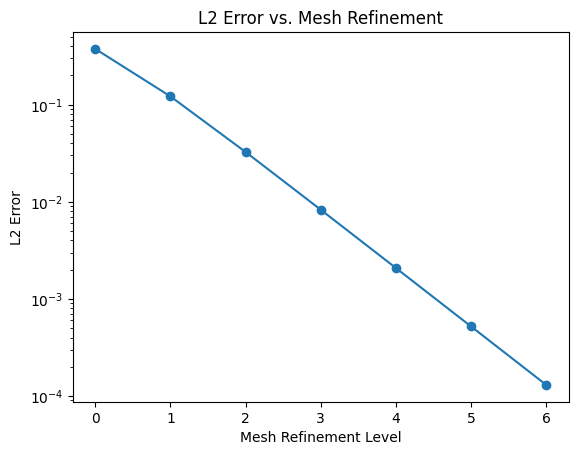

|Refinement|Error|
|:---:|:---:|
|0|0.37484770759594555|
|1|0.121555231367444|
|2|0.03255080912024765|
|3|0.00827870388764948|
|4|0.002078943950270176|
|5|0.0005203245744961888|
|6|0.0001301205520557702|



In [3]:
%%script false --no-raise-error

def u(x,y):
  return (x**2-1)*(y**2-1)

division = [1, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]

E=[]

for i in range(7):
    print("Mesh Refinement Level:", i)
    E_local = []
    V = FEM_V('./solutions/planar-quad/'+str(i)+'.csv', division[i])
    with tqdm.tqdm(total=160801, desc=f"Computing L2 Error for Level {i}") as pbar:
        for x in np.arange(-1, 1.005, 0.005):
            for y in np.arange(-1, 1.005, 0.005):
                u_value = V((x, y))
                U_exact = u(x, y)
                E_local.append((u_value - U_exact)**2)
                #print(f"Point: ({x}, {y}), FEM Value: {u_value}, Exact Value: {U_exact}, Squared Error: {(u_value - U_exact)**2}")
                pbar.update(1)
    print("L2 Error:", np.sqrt(np.mean(E_local)))
    E.append(np.sqrt(np.mean(E_local)))

file = open('./solutions/planar-quad/errors.csv','w')
file.write('Mesh Refinement Level,L2 Error\n')
for i in range(7):
    file.write(f'{i},{E[i]}\n')
file.close()

plt.figure()
plt.plot(range(0, 7), E, marker='o')
plt.title('L2 Error vs. Mesh Refinement')
plt.xlabel('Mesh Refinement Level')
plt.ylabel('L2 Error')
plt.xscale('linear')
plt.yscale('log')
plt.savefig('./solutions/planar-quad/error_plot.png')
plt.show()


Couldn't find program: 'false'


# Approximate Function 2

In [ ]:
import numpy as np

def round_key(p, ndigits=12):
    return (round(float(p[0]), ndigits), round(float(p[1]), ndigits))


def find_triangle(point, division):

    point = np.asarray(point, dtype=float)
    x, y = point

    grid_size = int(round(2 / division))

    x_index = int(np.floor((x + 1) / division))
    y_index = int(np.floor((y + 1) / division))

    x_index = max(0, min(x_index, grid_size - 1))
    y_index = max(0, min(y_index, grid_size - 1))

    x_min = -1 + x_index * division
    y_min = -1 + y_index * division
    x_max = x_min + division
    y_max = y_min + division

    p_i = np.array([x_min, y_min], dtype=float)  # bottom-left
    p_j = np.array([x_max, y_min], dtype=float)  # bottom-right
    p_k = np.array([x_min, y_max], dtype=float)  # top-left
    p_m = np.array([x_max, y_max], dtype=float)  # top-right

    # Local coordinates inside square cell
    sx = (x - x_min) / division
    sy = (y - y_min) / division

    # Same diagonal as your old farthest-corner method: p_j -- p_k
    if sx + sy <= 1.0:
        # lower-left triangle
        return p_i, p_j, p_k
    else:
        # upper-right triangle
        return p_m, p_k, p_j
    

def barycentric_coords(point, p1, p2, p3):

    point = np.asarray(point, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    A = np.column_stack((p2 - p1, p3 - p1))
    xi_eta = np.linalg.solve(A, point - p1)

    xi = xi_eta[0]
    eta = xi_eta[1]

    L1 = 1.0 - xi - eta
    L2 = xi
    L3 = eta

    return L1, L2, L3


def p2_basis(L1, L2, L3):

    return np.array([
        L1 * (2 * L1 - 1),   # vertex i
        L2 * (2 * L2 - 1),   # vertex j
        L3 * (2 * L3 - 1),   # vertex k
        4 * L2 * L3,         # midpoint j-k
        4 * L1 * L3,         # midpoint i-k
        4 * L1 * L2          # midpoint i-j
    ])

class FEM_V2:
    def __init__(self, domain_path, division):
        self.domain = self.get_domain(domain_path)
        self.division = division

    def get_domain(self, domain_path):
        domain = {}

        with open(domain_path, 'r') as f:
            lines = f.readlines()

            # remove header if present
            if not lines[0][0].isdigit() and not lines[0].startswith("-"):
                lines.pop(0)

            for line in lines:
                parts = line.strip().split(',')
                if len(parts) < 3:
                    continue

                x = float(parts[0])
                y = float(parts[1])
                u = float(parts[2])

                domain[round_key((x, y))] = u

        return domain

    def node_value(self, p):
        key = round_key(p)

        if key not in self.domain:
            raise KeyError(
                f"Node {key} not found in CSV. "
                "This usually means you are using a P1 solution file, "
                "or the midpoint nodes were not written to the CSV."
            )

        return self.domain[key]

    def get_value(self, point):
        point = np.asarray(point, dtype=float)

        # If the point is exactly a stored FEM node, return it directly
        key = round_key(point)
        if key in self.domain:
            return self.domain[key]

        # Find physical triangle
        p_i, p_j, p_k = find_triangle(point, self.division)

        # P2 midpoint nodes, matching ordering [i, j, k, m_jk, m_ik, m_ij]
        m_jk = 0.5 * (p_j + p_k)
        m_ik = 0.5 * (p_i + p_k)
        m_ij = 0.5 * (p_i + p_j)

        nodes = [
            p_i,
            p_j,
            p_k,
            m_jk,
            m_ik,
            m_ij
        ]

        U = np.array([self.node_value(p) for p in nodes])

        # Barycentric coordinates relative to p_i, p_j, p_k
        L1, L2, L3 = barycentric_coords(point, p_i, p_j, p_k)

        phi = p2_basis(L1, L2, L3)

        return float(np.dot(U, phi))

    def __call__(self, point):
        return self.get_value(point)

# Error Analysis 2

$$u(x,y)=(x^2-1)(y^2-1) \in \Gamma [-1,1] \times [-1,1]$$
$$-\Delta u = -2(x^2+y^2-2)$$
$$u(\Gamma_d) = 0 \Rightarrow g=0$$
$$E=|u-v|_{L^2(\Gamma)} \quad v \text{ is FEM Solution}$$

160,801 points from $[-1,1]\times[-1,1]$

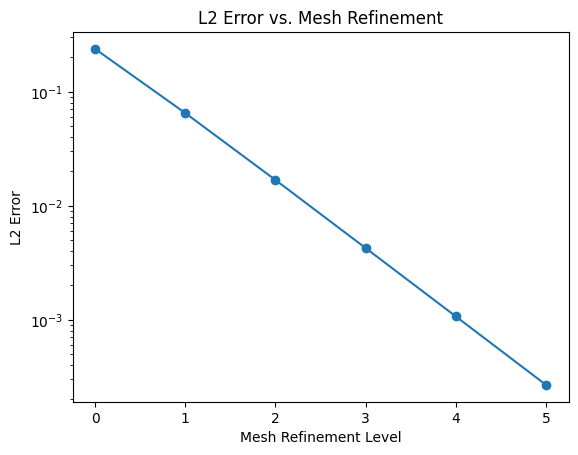

|Refinement|Error|
|:---:|:---:|
|0|0.2376961672282564|
|1|0.06499011105031435|
|2|0.016805686574328734|
|3|0.004246025278868562|
|4|0.0010664339822138397|
5|0.0002672650059132366|


Mesh Refinement Level: 0


Computing L2 Error for Level 0: 100%|██████████| 160801/160801 [00:04<00:00, 35760.91it/s]


L2 Error: 0.03221536458222604
Mesh Refinement Level: 1


Computing L2 Error for Level 1: 100%|██████████| 160801/160801 [00:04<00:00, 35708.72it/s]


L2 Error: 0.004070929231074266
Mesh Refinement Level: 2


...

L2 Error: 0.0005088626337668581
Mesh Refinement Level: 3


Computing L2 Error for Level 3: 100%|██████████| 160801/160801 [00:04<00:00, 33504.26it/s]


L2 Error: 6.365379864481256e-05
Mesh Refinement Level: 4


Computing L2 Error for Level 4: 100%|██████████| 160801/160801 [00:04<00:00, 33624.73it/s]


L2 Error: 7.950530766112185e-06


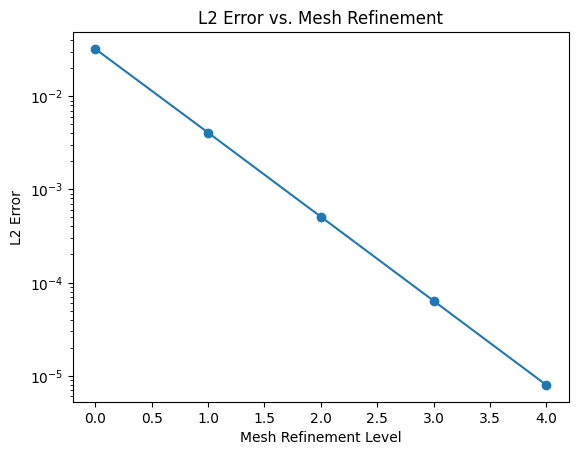

In [10]:
def u(x,y):
  return (x**2-1)*(y**2-1)

division = [1, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]

E=[]

for i in range(5):
    print("Mesh Refinement Level:", i)
    E_local = []
    V = FEM_V2(f'./solutions/planar-quad-O2/{i}.csv', division[i])
    with tqdm.tqdm(total=160801, desc=f"Computing L2 Error for Level {i}") as pbar:
        for x in np.arange(-1, 1.005, 0.005):
            for y in np.arange(-1, 1.005, 0.005):
                u_value = V((x, y))
                U_exact = u(x, y)
                E_local.append((u_value - U_exact)**2)
                #print(f"Point: ({x}, {y}), FEM Value: {u_value}, Exact Value: {U_exact}, Squared Error: {(u_value - U_exact)**2}")
                pbar.update(1)
    print("L2 Error:", np.sqrt(np.mean(E_local)))
    E.append(np.sqrt(np.mean(E_local)))

file = open('./solutions/planar-quad-O2/errors.csv','w')
file.write('Mesh Refinement Level,L2 Error\n')
for i in range(5):
    file.write(f'{i},{E[i]}\n')
file.close()

plt.figure()
plt.plot(range(0, 5), E, marker='o')
plt.title('L2 Error vs. Mesh Refinement')
plt.xlabel('Mesh Refinement Level')
plt.ylabel('L2 Error')
plt.xscale('linear')
plt.yscale('log')
plt.savefig('./solutions/planar-quad-O2/error_plot.png')
plt.show()
